In [1]:
import os
import qsprpred
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a depende

In [2]:
X1 = pd.read_csv("A2AR/mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("A2AR/mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("A2AR/mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("A2AR/mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("A2AR/mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("A2AR/mod_data/y3.1", index_col="QSPRID")


In [3]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [4]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=1, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))

,0,1,2,3,4,5,6,7,8,9,...,3066,3067,3068,3069,3070,3071,3072,3073,3074,3075
0,0.629350,0.409822,0.114763,0.849649,-1.302256,-1.582738,-0.678928,-1.233195,-1.434335,-1.134524,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,1.233341
1,1.225274,0.942670,-0.168389,-0.169440,-0.341978,-0.052202,2.212653,0.803415,0.814574,0.266891,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,4.974340,-0.279983,-1.882446
2,-0.982475,0.726753,-1.033329,1.253848,-0.652347,0.063208,0.950025,-0.664100,-1.904197,-1.753757,...,-0.081803,2.465924,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,2.249445
3,1.324123,1.301264,0.499300,-2.170308,-0.573437,-1.556576,0.760613,0.555091,-0.346715,-0.279360,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,2.389444,-0.279983,-1.263797
4,0.402699,0.209699,0.333955,1.363094,-1.035884,-1.581501,-0.340915,-0.499982,-1.004890,-1.360252,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,1.151519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4629,1.032254,0.229924,0.599687,-2.032301,-0.221510,-0.969474,0.562910,0.238983,-1.371945,-0.892411,...,-0.081803,1.057649,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,-1.090632
4630,0.852744,2.780378,-0.303757,0.045130,-0.705685,0.354237,2.359929,0.399819,-0.237312,-0.480343,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,-0.886180
4631,1.077851,0.406309,0.009425,-2.073997,-0.936921,-0.010000,0.142849,-0.608348,-0.839790,-0.252830,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,0.321485
4632,0.728076,1.615808,0.402721,-0.872904,-0.449266,0.046455,1.877900,0.718067,-0.754062,-0.452396,...,-0.081803,1.411798,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,-1.019934


In [4]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit_transform(X1)

array([[-7.03381861e+00,  3.03691403e-01, -6.19547970e+00, ...,
         4.75197773e-01, -7.70093919e-03, -4.77526099e-01],
       [ 2.34792569e+01, -1.08840876e+01,  3.12616799e+00, ...,
        -6.93788817e-01, -1.14408402e+00,  1.25100357e+00],
       [-4.07782819e+00, -1.83159429e+00, -9.68935360e+00, ...,
        -3.07389420e-01, -2.34450217e-01, -1.41235658e-02],
       ...,
       [-7.78253209e+00, -3.15100847e+00,  4.37393982e+00, ...,
        -8.51127718e-01, -1.62175377e-01, -8.93517698e-01],
       [-9.63827446e+00, -4.51158549e+00, -1.88168587e+00, ...,
         4.15923723e-01, -1.69596074e-02, -1.83186781e-01],
       [-9.88060683e+00, -5.29923812e+00,  4.24504733e+00, ...,
         7.91015689e-01, -9.65617790e-01, -9.30368873e-01]])

In [5]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1

In [6]:
n_components

851

In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

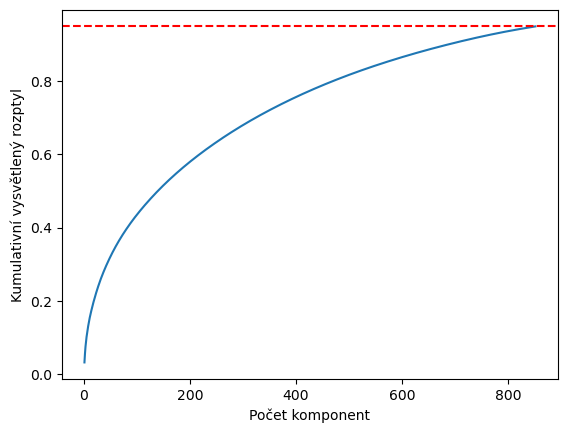

In [8]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [9]:

# Přidejte cestu k vašemu lokálnímu repozitáři
import sys
import os

# Přidání cesty k lokálnímu repozitáři na začátek sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Zkontrolujte, zda je cesta v sys.path
print(sys.path)

from importlib import reload

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected
# Znovu načtěte modul, abyste zajistili, že je správně importován
reload(sys.modules['qsprpred.extra.gpu.models.neural_network'])

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected

os.chdir('/home/ubuntu/Bakalarka/QSPRpred')
print(os.getcwd())


import sys
import importlib.util

# Přidání cesty k repozitáři do sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Specifikujte cestu k souboru, který chcete importovat
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/neural_network.py'
module_name = 'qsprpred.extra.gpu.models.neural_network'

# Načtěte modul z konkrétní cesty
spec = importlib.util.spec_from_file_location(module_name, module_path)
neural_network = importlib.util.module_from_spec(spec)
spec.loader.exec_module(neural_network)

# Nyní můžete používat třídu STFullyConnected
STFullyConnected = neural_network.STFullyConnected

['/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python311.zip', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/lib-dynload', '', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages']
/home/ubuntu/Bakalarka/QSPRpred
lol


In [10]:
import optuna
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score

def objective(trial, X_train, y_train, X_val, y_val):
    """Definice cílové funkce pro Optunu"""

    # Návrh hyperparametrů pro dopřednou neuronovou síť
    params = {
        'dropout_frac': trial.suggest_float("dropout_frac", 0, 0.9),
        'patience': trial.suggest_int("patience", 10, 200),
        'tol': trial.suggest_float("tol", 1e-5, 1e-2, log=True),
        'weight_decay': trial.suggest_float("weight_decay", 1e-6, 1e-1, log=True),
        'n_epochs': trial.suggest_int("n_epochs", 200, 2000),
        'batch_size': trial.suggest_categorical("batch_size", [64, 128, 256, 512, 1024]),
        'optimizer': trial.suggest_categorical("optimizer", ["AdamW", "RMSprop"]),
        'lr': trial.suggest_categorical("lr", [1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]),
        'neuron_layers': trial.suggest_categorical("neuron_layers_size", ["[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]", "[2048, 1024, 512, 256, 128, 64, 32, 16, 8]", "[4096, 1024, 256, 64, 8]", "[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]", "[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]", "[200]", "[2000]", "[2000, 1000]", "[2000, 1000, 500]", "[1000, 50]", "[4000, 2000]", "[4000, 2000, 1000, 500]", "[4000, 2000, 2000, 500]"])
    }

    neuron_layers_dict = {
        "[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]": [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8],
        "[2048, 1024, 512, 256, 128, 64, 32, 16, 8]": [2048, 1024, 512, 256, 128, 64, 32, 16, 8],
        "[4096, 1024, 256, 64, 8]": [4096, 1024, 256, 64, 8],
        "[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]": [4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8],
        "[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]": [4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096],
        "[200]": [200],
        "[2000]": [2000],
        "[2000, 1000]": [2000, 1000],
        "[2000, 1000, 500]": [2000, 1000, 500],
        "[1000, 50]": [1000, 50],
        "[4000, 2000]": [4000, 2000],
        "[4000, 2000, 1000, 500]": [4000, 2000, 1000, 500],
        "[4000, 2000, 2000, 500]": [4000, 2000, 2000, 500]
    }
    params['neuron_layers'] = neuron_layers_dict[params['neuron_layers']]
    opt_func = optim.AdamW if params['optimizer'] == "AdamW" else optim.RMSprop

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Model
    model = STFullyConnected(
        n_dim=X_train.shape[1],
        n_class=1,
        device=device,
        act_fun=F.selu,
        dropout_frac=params['dropout_frac'],
        patience=params['patience'],
        tol=params['tol'],  # Opraveno: nyní používáme hodnotu z trial
        weight_decay=params['weight_decay'],
        n_epochs=params['n_epochs'],
        neuron_layers=params['neuron_layers'],  # Použití neuron_layers_size
        batch_size=params['batch_size'],
        optimizer=opt_func,
        lr=params['lr'],
    )
    # Trénink a predikce
    model.fit(X_train, y_train, X_val, y_val)
    preds = model.predict(X_val)
    preds_bin = preds > 0.5

    # Metiky
    f1 = f1_score(y_val, preds_bin)
    acc = accuracy_score(y_val, preds_bin)
    mcc = matthews_corrcoef(y_val, preds_bin)

    # Můžeš logovat i do trialu
    trial.set_user_attr("f1", f1)
    trial.set_user_attr("acc", acc)
    display(confusion_matrix(y_val, preds_bin))
    return mcc  # maximalizujeme MCC


In [ ]:
study = optuna.create_study(
    study_name="A2AR_new_roberta_mol2vec_without_smote_pca",  # jméno pro pozdější načtení
    direction="maximize",
    sampler=optuna.samplers.NSGAIISampler(),
    storage="sqlite:///optuna_results.db",
    load_if_exists=True  # pokud už existuje, nepřepíše ji
)

# Spusť optimalizaci
study.optimize(
    lambda trial: objective(trial, X1, y1, X2, y2),
    n_trials=2000
)
print("Best MCC:", study.best_value)
print("Best parameters:", study.best_params)

# Pokud chceš F1 a ACC u nejlepšího modelu:
print("Best F1:", study.best_trial.user_attrs["f1"])
print("Best ACC:", study.best_trial.user_attrs["acc"])

[I 2025-05-19 06:05:15,065] Using an existing study with name 'A2AR_new_roberta_mol2vec_without_smote_pca' instead of creating a new one.


array([[ 16,  14],
       [ 46, 735]])

[I 2025-05-19 06:08:16,253] Trial 321 finished with value: 0.336996693864269 and parameters: {'dropout_frac': 0.627458241076343, 'patience': 156, 'tol': 0.00014102360346172704, 'weight_decay': 0.00016391905402967627, 'n_epochs': 1979, 'batch_size': 256, 'optimizer': 'RMSprop', 'lr': 0.0001, 'neuron_layers_size': '[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]'}. Best is trial 246 with value: 0.4067299540117643.


array([[  0,  30],
       [  0, 781]])

[I 2025-05-19 06:08:38,844] Trial 322 finished with value: 0.0 and parameters: {'dropout_frac': 0.5088979504647838, 'patience': 35, 'tol': 0.00014102360346172704, 'weight_decay': 0.00010505736716440249, 'n_epochs': 1979, 'batch_size': 256, 'optimizer': 'RMSprop', 'lr': 0.001, 'neuron_layers_size': '[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]'}. Best is trial 246 with value: 0.4067299540117643.


...

[I 2025-05-19 15:32:32,012] Trial 779 finished with value: -0.009744865458384941 and parameters: {'dropout_frac': 0.5466948022142591, 'patience': 111, 'tol': 5.0148696309943876e-05, 'weight_decay': 0.00018087166775881784, 'n_epochs': 1279, 'batch_size': 256, 'optimizer': 'RMSprop', 'lr': 0.01, 'neuron_layers_size': '[2000, 1000, 500]'}. Best is trial 710 with value: 0.4984213583866285.


array([[ 10,  20],
       [224, 557]])

[I 2025-05-19 15:33:09,648] Trial 780 finished with value: 0.01937958703712111 and parameters: {'dropout_frac': 0.5466948022142591, 'patience': 111, 'tol': 0.007933622074093252, 'weight_decay': 0.00018087166775881784, 'n_epochs': 1279, 'batch_size': 1024, 'optimizer': 'RMSprop', 'lr': 0.001, 'neuron_layers_size': '[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]'}. Best is trial 710 with value: 0.4984213583866285.


array([[ 10,  20],
       [ 12, 769]])

[I 2025-05-19 15:35:43,939] Trial 781 finished with value: 0.36941990001706415 and parameters: {'dropout_frac': 0.5466948022142591, 'patience': 111, 'tol': 0.00014102360346172704, 'weight_decay': 0.00016391905402967627, 'n_epochs': 1279, 'batch_size': 128, 'optimizer': 'RMSprop', 'lr': 0.0001, 'neuron_layers_size': '[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]'}. Best is trial 710 with value: 0.4984213583866285.


In [20]:
test = study.best_params
test["neuron_layers"] = eval(test["neuron_layers_size"])
test["optimizer"] = eval("optim."+test["optimizer"])
test.pop("neuron_layers_size")
print(test)

{'dropout_frac': 0.45219745872494244, 'patience': 67, 'tol': 0.00042627414813065605, 'weight_decay': 0.0017370910730011011, 'n_epochs': 264, 'batch_size': 256, 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'lr': 1e-06, 'neuron_layers': [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]}


In [25]:

model = STFullyConnected(
        n_dim=X1.shape[1],
        n_class=1,
        device="cuda",
        act_fun=F.selu,
    print_outputs= 2,
    **test
    )
model.fit(X1,y1,X2,y2) #0.6084853456048988

Epoch 1 | Train Loss: 0.6931 | Valid Loss: 0.7156 | MCC: -0.0096
Epoch 2 | Train Loss: 0.7531 | Valid Loss: 0.7151 | MCC: -0.0051
Epoch 3 | Train Loss: 0.7147 | Valid Loss: 0.7146 | MCC: -0.0051
Epoch 4 | Train Loss: 0.6705 | Valid Loss: 0.7141 | MCC: -0.0010
Epoch 5 | Train Loss: 0.6542 | Valid Loss: 0.7136 | MCC: -0.0275
Epoch 6 | Train Loss: 0.7209 | Valid Loss: 0.7130 | MCC: -0.0239
Epoch 7 | Train Loss: 0.7536 | Valid Loss: 0.7124 | MCC: -0.0195
Epoch 8 | Train Loss: 0.6662 | Valid Loss: 0.7117 | MCC: -0.0105
Epoch 9 | Train Loss: 0.7588 | Valid Loss: 0.7110 | MCC: -0.0009
Epoch 10 | Train Loss: 0.6319 | Valid Loss: 0.7102 | MCC: 0.0061
Epoch 11 | Train Loss: 0.7277 | Valid Loss: 0.7094 | MCC: 0.0198
Epoch 12 | Train Loss: 0.7354 | Valid Loss: 0.7084 | MCC: 0.0229
Epoch 13 | Train Loss: 0.6607 | Valid Loss: 0.7074 | MCC: 0.0322
Epoch 14 | Train Loss: 0.6856 | Valid Loss: 0.7064 | MCC: 0.0413
Epoch 15 | Train Loss: 0.6677 | Valid Loss: 0.7053 | MCC: 0.0542
Epoch 16 | Train Loss: 0.

(STFullyConnected(
   (layers): ModuleList(
     (0): Linear(in_features=741, out_features=4096, bias=True)
     (1): Linear(in_features=4096, out_features=2048, bias=True)
     (2): Linear(in_features=2048, out_features=1024, bias=True)
     (3): Linear(in_features=1024, out_features=512, bias=True)
     (4): Linear(in_features=512, out_features=256, bias=True)
     (5): Linear(in_features=256, out_features=128, bias=True)
     (6): Linear(in_features=128, out_features=64, bias=True)
     (7): Linear(in_features=64, out_features=32, bias=True)
     (8): Linear(in_features=32, out_features=16, bias=True)
     (9): Linear(in_features=16, out_features=8, bias=True)
     (10): Linear(in_features=8, out_features=1, bias=True)
   )
   (dropout): Dropout(p=0.45219745872494244, inplace=False)
   (criterion): BCEWithLogitsLoss()
 ),
 115)

In [26]:
preds = model.predict(X2)
preds_bin = preds > 0.5

mcc = matthews_corrcoef(y2, preds_bin)
display(mcc)

0.49006400964679797

In [28]:
preds = model.predict(X3)
preds_bin = preds > 0.5

    # Metiky
f1 = f1_score(y3, preds_bin)
acc = accuracy_score(y3, preds_bin)
mcc = matthews_corrcoef(y3, preds_bin)

In [29]:
display(mcc) # 0.17324800323685596

0.3645163423049995

In [25]:

# Přidejte cestu k vašemu lokálnímu repozitáři
import sys
import os

# Přidání cesty k lokálnímu repozitáři na začátek sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Zkontrolujte, zda je cesta v sys.path
print(sys.path)

from importlib import reload

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected
# Znovu načtěte modul, abyste zajistili, že je správně importován
reload(sys.modules['qsprpred.extra.gpu.models.neural_network'])

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected

os.chdir('/home/ubuntu/Bakalarka/QSPRpred')
print(os.getcwd())


import sys
import importlib.util

# Přidání cesty k repozitáři do sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Specifikujte cestu k souboru, který chcete importovat
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/neural_network.py'
module_name = 'qsprpred.extra.gpu.models.neural_network'

# Načtěte modul z konkrétní cesty
spec = importlib.util.spec_from_file_location(module_name, module_path)
neural_network = importlib.util.module_from_spec(spec)
spec.loader.exec_module(neural_network)

# Nyní můžete používat třídu STFullyConnected
STFullyConnected = neural_network.STFullyConnected

['/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python311.zip', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/lib-dynload', '', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/setuptools/_vendor', '/tmp/tmp5tfx0zz9']
/home/ubuntu/Bakalarka/QSPRpred
lol
